**Waste Segregation System**

To develop an waste segregation system that classifies waste images into different categories using CNN model.

In [1]:
!pip install Kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("feyzazkefe/trashnet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'trashnet' dataset.
Path to dataset files: /kaggle/input/trashnet


Import Libraries

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Tensorflow version: ",tf.__version__)

Tensorflow version:  2.20.0


In [4]:
dataset_path = os.path.join(path,"dataset-resized")

print("classes: ")
print(os.listdir(dataset_path))

classes: 
['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


In [5]:
classes=os.listdir(dataset_path)
data=[]

for class_name in classes:
  class_path=os.path.join(dataset_path,class_name)
  count=len([file for file in os.listdir(class_path) if file.lower().endswith(('.jpg','.jpeg','.png'))])
  data.append([class_name,count])
df=pd.DataFrame(data,columns=['Class','Image_Count'])
df

,Class,Image_Count
0,metal,410
1,glass,501
2,paper,594
3,trash,137
4,cardboard,403
5,plastic,482


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class        6 non-null      object
 1   Image_Count  6 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.isnull().sum()

,0
Class,0
Image_Count,0


This helps us understand whether the dataset is balanced or imbalanced.

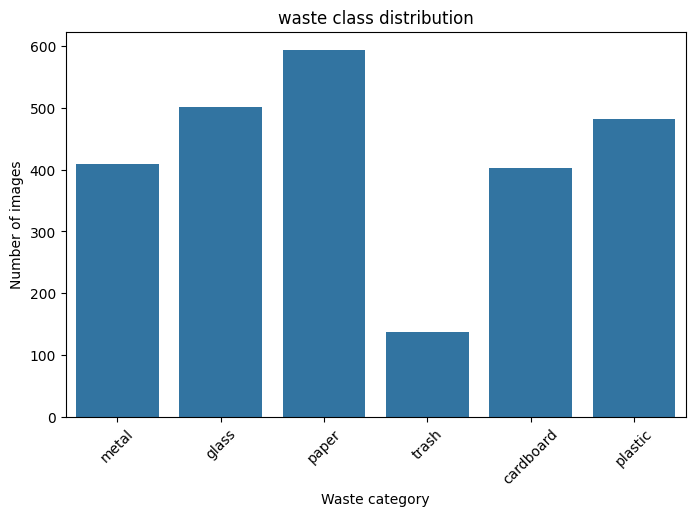

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Class',
    y='Image_Count',
    data=df
)

plt.title("waste class distribution")
plt.xlabel("Waste category")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.show()

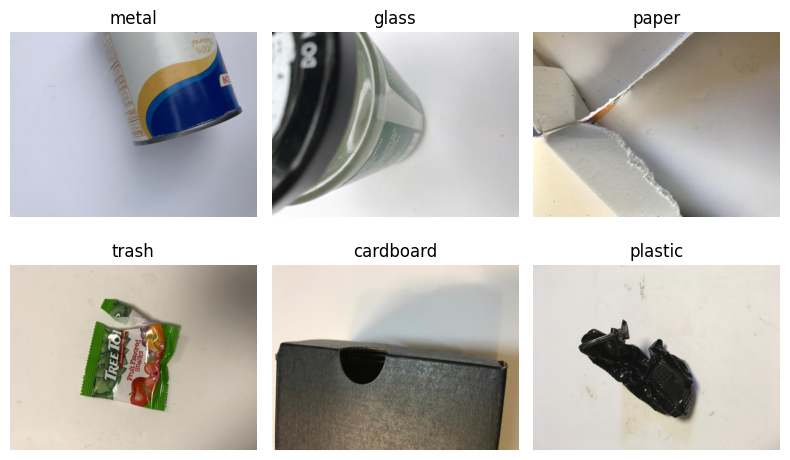

In [7]:
#display sample images
plt.figure(figsize=(8,5))
for i,class_name in enumerate(classes):
  class_path=os.path.join(dataset_path,class_name)
  image_files=[file for file in os.listdir(class_path) if file.lower().endswith(('.jpg','.jpeg','.png'))]
  image_path=os.path.join(class_path,image_files[0])
  image=plt.imread(image_path)

  plt.subplot(2,3,i+1)
  plt.imshow(image)
  plt.title(class_name)
  plt.axis("off")

plt.tight_layout()
plt.show()

transfer learning using mobilenetv2

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential

base_model=MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable=False

mobilenet_model=Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(6,activation="softmax")
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen_m=ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

val_datagen_m=ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [11]:
train_generator_m=train_datagen_m.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    subset="training",
    shuffle=True
)

validation_generator_m=val_datagen_m.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [12]:
print(train_generator_m.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [13]:
history_m=mobilenet_model.fit(
    train_generator_m,
    validation_data=validation_generator_m,
    epochs=30
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.6566 - loss: 0.9822 - val_accuracy: 0.7197 - val_loss: 0.7038
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7703 - loss: 0.6115 - val_accuracy: 0.7058 - val_loss: 0.7508
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8147 - loss: 0.5195 - val_accuracy: 0.7495 - val_loss: 0.6798
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8315 - loss: 0.4613 - val_accuracy: 0.7773 - val_loss: 0.6130
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8493 - loss: 0.4120 - val_accuracy: 0.7495 - val_loss: 0.6693
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8552 - loss: 0.3816 - val_accuracy: 0.7734 - val_loss: 0.6541
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8646 - loss: 0.3806 - val_accuracy: 0.7972 - val_loss: 0.6211
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8775 - loss: 0.3328 - val_accuracy: 0.7614 - v

In [43]:
loss_m,accuracy_m=mobilenet_model.evaluate(validation_generator_m)
print("validation loss:",loss_m)
print("validation accuracy:",accuracy_m)

16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8171 - loss: 0.7573
validation loss: 0.7573107481002808
validation accuracy: 0.8170974254608154


In [38]:
#fine-tuning
base_model.trainable=True

for layer in base_model.layers[:-30]:
  layer.trainable=False

for layer in base_model.layers:
  if isinstance(layer,tf.keras.layers.BatchNormalization):
    layer.trainable=False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune=mobilenet_model.fit(
    train_generator_m,
    validation_data=validation_generator_m,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.9506 - loss: 0.1377 - val_accuracy: 0.8052 - val_loss: 0.7319
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9625 - loss: 0.1027 - val_accuracy: 0.8032 - val_loss: 0.7189
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.9595 - loss: 0.1131 - val_accuracy: 0.8091 - val_loss: 0.7589
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9684 - loss: 0.0911 - val_accuracy: 0.8191 - val_loss: 0.7615
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.9738 - loss: 0.0805 - val_accuracy: 0.8111 - val_loss: 0.7185
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9718 - loss: 0.0839 - val_accuracy: 0.8032 - val_loss: 0.7176
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.9723 - loss: 0.0828 - val_accuracy: 0.8131 - val_loss: 0.7379
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.9723 - loss: 0.0759 - val_accuracy: 0.8072 - v

In [60]:
loss,accuracy=mobilenet_model.evaluate(validation_generator_m)
print("validation loss:",loss)
print("validation accuracy:",accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8032 - loss: 0.7626
validation loss: 0.7625751495361328
validation accuracy: 0.8031809329986572


In [61]:
validation_generator_m.reset()
predictions_m=mobilenet_model.predict(validation_generator_m)
y_pred_m=np.argmax(predictions_m,axis=1)
y_true_m=validation_generator_m.classes

class_names_m=list(validation_generator_m.class_indices.keys())
print("classes:",class_names_m)

16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


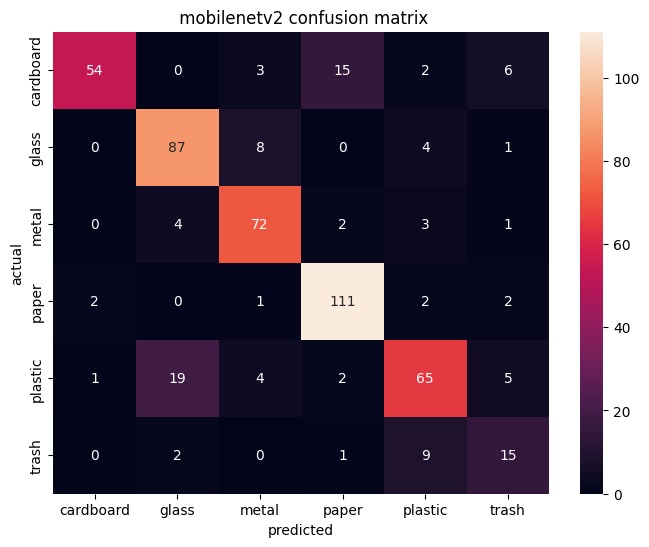

In [62]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_m=confusion_matrix(y_true_m,y_pred_m)

plt.figure(figsize=(8,6))
sns.heatmap(cm_m,
            annot=True,
            fmt="d",
            xticklabels=class_names_m,
            yticklabels=class_names_m)

plt.title(" mobilenetv2 confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

In [63]:
#classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_m,
        y_pred_m,
        target_names=class_names_m))

              precision    recall  f1-score   support

   cardboard       0.95      0.68      0.79        80
       glass       0.78      0.87      0.82       100
       metal       0.82      0.88      0.85        82
       paper       0.85      0.94      0.89       118
     plastic       0.76      0.68      0.72        96
       trash       0.50      0.56      0.53        27

    accuracy                           0.80       503
   macro avg       0.78      0.77      0.77       503
weighted avg       0.81      0.80      0.80       503



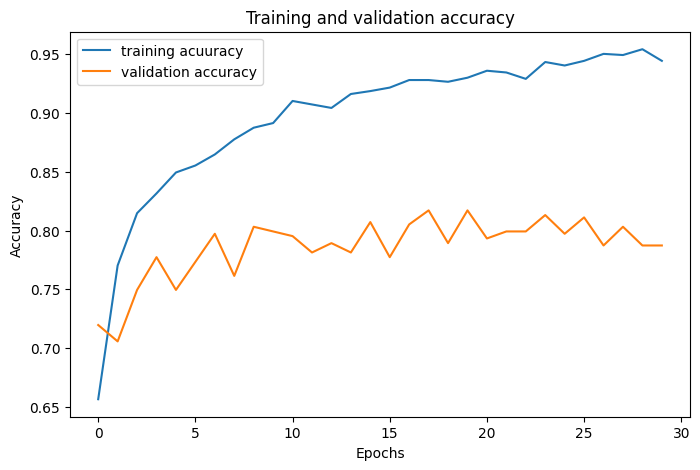

In [64]:
#accuracy graph
plt.figure(figsize=(8,5))
plt.plot(
    history_m.history["accuracy"],
    label="training acuuracy"
)

plt.plot(
    history_m.history["val_accuracy"],
    label="validation accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [71]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

image_path = "/content/g4.jpg"
img = load_img(
    image_path,
    target_size=(224, 224)
)

image_array = img_to_array(img)
image_array = preprocess_input(image_array)
image_array = np.expand_dims(image_array, axis=0)

prediction = mobilenet_model.predict(image_array)

prediction_index = np.argmax(prediction[0])
prediction_class = class_names_m[prediction_index]
confidence = prediction[0][prediction_index] * 100

print("Predicted index:", prediction_index)
print("Predicted class:", prediction_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Predicted index: 1
Predicted class: glass
Confidence: 100.0 %


In [73]:
mobilenet_model.save("waste_segregation_system.keras")

print("Saved: waste_segregation_system.keras")

Saved: waste_segregation_system.keras


In [74]:
mobilenet_model.save("waste_segregation_system.h5")

print("Saved: waste_segregation_system.h5")

Saved: waste_segregation_system.h5


In [76]:
mobilenet_model.export("waste_segregation_system_saved_model")

print("Saved TensorFlow SavedModel to: waste_segregation_system_saved_model/")

Saved artifact at 'waste_segregation_system_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139180583363472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139180583367888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139180583368656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139180583369808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139180583370576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139180583369040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139180583360784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139180583368464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139180583368848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139180583364240: TensorSpec(shape=(), dtype=tf.resource, nam

In [77]:
loaded_model = tf.keras.models.load_model("waste_segregation_system.keras")

print("Model loaded successfully.")
print("Input shape:", loaded_model.input_shape)

Model loaded successfully.
Input shape: (None, 224, 224, 3)
